In [1]:
# Importación de librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## A) Con el archivo spotify.csv realiza lo siguiente:

In [2]:
df = pd.read_csv('spotify.csv', encoding='ISO-8859-1')
df

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,AirPlay Spins,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,"40,975",684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",0
1,Not Like Us,Not Like Us,Kendrick Lamar,05/04/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,"40,778",3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,"74,333",536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",0
3,Flowers,Flowers - Single,Miley Cyrus,01/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"1,474,799","2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,"12,185",1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,09/05/2017,QM8DG1703420,"4,585",19.4,"305,049,963","65,770","5,103,054",...,6,NaN,2.0,"14,217",NaN,"20,104,066","13,184","50,633,006","656,337",1
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,7/27/2018,INT101800122,"4,575",19.4,"52,282,360","4,602","1,449,767",...,412,NaN,1.0,927,NaN,NaN,NaN,NaN,"193,590",0
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2/28/2020,USUG12000043,"4,571",19.4,"189,972,685","72,066","6,704,802",...,204,NaN,1.0,74,6.0,"84,426,740","28,999",NaN,"1,135,998",1
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,11/08/2016,INY091600067,"4,591",19.4,"145,467,020","14,037","7,387,064",...,"1,200",NaN,NaN,NaN,7.0,"6,817,840",NaN,NaN,"448,292",0


### 1. Sustituye los valores vacíos “” por NA en todas las columnas que lo requieran.

In [3]:
df = df.replace('', pd.NA)

### 2. ¿Cuántas observaciones del dataframe se encuentran completas?

In [4]:
df.notnull().all(axis=1).sum()

"""
# Tambien se pudo haber eliminado las filas vacias y sacado el numero de registros con "shape"
filas_completas = df.dropna()
filas_completas.shape[0]
"""

'\n# Tambien se pudo haber eliminado las filas vacias y sacado el numero de registros con "shape"\nfilas_completas = df.dropna()\nfilas_completas.shape[0]\n'

### 3. ¿Cuál es el nombre de las columnas que tienen valores con NA?

In [5]:
condicion = df.isnull().sum() == 0
df.keys()[~condicion].tolist()

['Artist',
 'Spotify Streams',
 'Spotify Playlist Count',
 'Spotify Playlist Reach',
 'Spotify Popularity',
 'YouTube Views',
 'YouTube Likes',
 'TikTok Posts',
 'TikTok Likes',
 'TikTok Views',
 'YouTube Playlist Reach',
 'Apple Music Playlist Count',
 'AirPlay Spins',
 'SiriusXM Spins',
 'Deezer Playlist Count',
 'Deezer Playlist Reach',
 'Amazon Playlist Count',
 'Pandora Streams',
 'Pandora Track Stations',
 'Soundcloud Streams',
 'Shazam Counts']

### 4. ¿Cuál es la posición en el ranking de todos los tiempos de la canción Danza Kuduro – Cover?

In [6]:
"""
Otra forma es como la siguiente, donde tambien muestra todas las posiciones donde aparece
df[df['Track'] == 'Danza Kuduro - Cover']['All Time Rank']
"""

df.loc[df['Track'] == 'Danza Kuduro - Cover', ['All Time Rank']].min() # Saca el primer resultado de la columna

All Time Rank    1,097
dtype: object

### 5. ¿Cuál es el nombre de la canción ubicada en el primer lugar del ranking de todos los tiempos?

In [7]:
# Forma 1
df.loc[df['All Time Rank'] == '1', ['Track']]

,Track
0,MILLION DOLLAR BABY


In [8]:
# Forma 2
df[df['All Time Rank'] == '1']['Track'][0]

'MILLION DOLLAR BABY'

### 6. ¿Cuál es la popularidad de la canción de la pregunta 5 en Spotify?

In [9]:
# Forma 1
df.loc[df['All Time Rank'] == '1', ['Spotify Popularity']]

,Spotify Popularity
0,92.0


In [10]:
# Forma 2
cancion = df[df['All Time Rank'] == '1']['Track'][0]
df[df['Track'] == cancion]['Spotify Popularity']

0    92.0
Name: Spotify Popularity, dtype: float64

### 7. ¿Cuál es el nombre de la canción con más likes en YouTube?

In [11]:
"""
# Otra forma hubiera sido de la siguiente manera, ya que "astype(float)" convierte los valores vacíos a NaN y max() los ignora
maximo = df['YouTube Likes'].str.replace(',','').astype(float).max()
df[df['YouTube Likes'].str.replace(',','').astype(float) == maximo]['Track']
"""

# Reemplazar las comas para poder convertir
df['YouTube Likes'] = df['YouTube Likes'].str.replace(',' , '')
# Rellenar los NaN
df['YouTube Likes'] = df['YouTube Likes'].fillna(0)
# Convertir a enteros
df['YouTube Likes'] = df['YouTube Likes'].astype(int)

# Canción con mas likes obtenida
mas_likes_youtube = df['YouTube Likes'].max()
df.loc[df['YouTube Likes'] == mas_likes_youtube, ['Track']]

,Track
130,Dynamite


### 8. ¿Cuántas canciones explícitas se encuentran en el dataframe?

In [12]:
# Forma 1
(df['Explicit Track'] == 1).sum()

np.int64(1651)

In [13]:
# Forma 2
df[df['Explicit Track'] == 1].shape[0]

1651

### 9. Sustituye los valores con NA de la columna Amazon Playlist Count por el promedio.

In [14]:
promedio = df['Amazon Playlist Count'].mean()
df['Amazon Playlist Count'] = df['Amazon Playlist Count'].fillna(promedio)

### 10. Sustituye los valores con NA de la columna Shazam Counts por la moda.

In [15]:
moda = df['Shazam Counts'].mode()[0]
df['Shazam Counts'] = df['Shazam Counts'].fillna(moda)

## B) Gráfica los datos de la columna Track Score y contesta la siguiente:

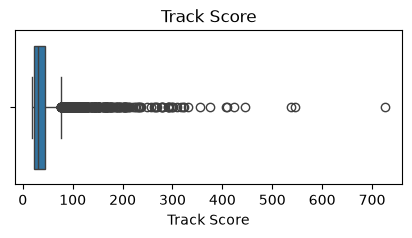

In [16]:
plt.figure(figsize=(5,2))
sns.boxplot(x=df['Track Score'])
plt.title('Track Score')
plt.show()

### 1. ¿Cuántos valores atípicos tiene la columna Track Score?

In [17]:
# Calcular limites
Q1 = df['Track Score'].quantile(0.25)
Q3 = df['Track Score'].quantile(0.75)
limite_inferior = Q1 - 1.5 * (Q3 - Q1)
limite_superior = Q3 + 1.5 * (Q3 - Q1)
# Filtrar datos
df[(df['Track Score'] < limite_inferior) | ( df['Track Score'] > limite_superior) ].shape[0]

406

### 2. Elimina los valores atípicos y devuelve la cantidad de registros resultante al eliminarlos.

In [18]:
df = df[(df['Track Score'] >= limite_inferior) & ( df['Track Score'] <= limite_superior)]
df.shape[0]

4194